# 針葉樹 / 広葉樹 分類 — 1600–1800 nm 帯 + SNV + 1D-CNN

NIRスペクトル(波数 cm⁻¹ 降順, 1000–2500 nm)から **針葉樹 / 広葉樹** を判定。

- 帯: **1600–1800 nm**(= 6250–5556 cm⁻¹, C-H 1st overtone 近傍)。
- 前処理: **SNV(行単位)のみ**。
- 分類: SNVスペクトルを **1D-CNN** に入力。畳み込み層が局所特徴を抽出。

train/testは樹種が完全別集合 → LOSOで外挿を見積り、全trainで最終学習しtestを評価。

In [1]:
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
matplotlib.rcParams['font.family'] = ['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False
import torch, torch.nn as nn
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
torch.manual_seed(0); np.random.seed(0)
print('torch', torch.__version__)

torch 2.12.0


In [2]:
tr = pd.read_csv('../data/train_clean.csv', encoding='shift_jis')
te = pd.read_csv('../data/test.csv', encoding='shift_jis')
SP='樹種'
wn_cols=[c for c in tr.columns if c not in ['sample number','species number','樹種','含水率']]
wn=np.array([float(c) for c in wn_cols]); wl=1e7/wn
print('train',tr.shape,'test',te.shape,'| pts',len(wn),'| 波数間隔~%.3f cm-1'%abs(np.diff(wn).mean()))
print('train sp',list(tr[SP].unique())); print('test sp',list(te[SP].unique()))

train (1270, 1559) test (550, 1558) | pts 1555 | 波数間隔~3.857 cm-1
train sp ['イチョウ', 'ウエンジ', 'ウォールナット', 'クリ', 'スプルース', 'チェリー', 'トチ', 'ナラ', 'ヒノキ', 'ベイスギ', '米ヒバ', 'ベイマツ', 'ホワイトオーク']
test sp ['クスノキ', 'ケヤキ', 'スギ', 'タモ', 'チーク', 'ヤマザクラ']


In [3]:
# 針葉樹/広葉樹 ラベル(イチョウ=裸子植物・無道管材→針葉樹側)
CONIFER={'スプルース','ヒノキ','ベイスギ','米ヒバ','ベイマツ','イチョウ','スギ'}
BROAD={'ウエンジ','ウォールナット','クリ','チェリー','トチ','ナラ','ホワイトオーク',
       'クスノキ','ケヤキ','タモ','チーク','ヤマザクラ'}
def lab(s): return 1 if s in CONIFER else 0
for df in (tr,te):
    df['label']=df[SP].map(lab); df['class']=df['label'].map({1:'針葉樹',0:'広葉樹'})
print(tr.groupby(['class',SP]).size(),'\n'); print(te.groupby(['class',SP]).size())

class  樹種     
広葉樹    ウエンジ        87
       ウォールナット    110
       クリ          91
       チェリー        88
       トチ         183
       ナラ         107
       ホワイトオーク     51
針葉樹    イチョウ        94
       スプルース       97
       ヒノキ        141
       ベイスギ        60
       ベイマツ        93
       米ヒバ         68
dtype: int64 

class  樹種   
広葉樹    クスノキ      96
       ケヤキ       63
       タモ        45
       チーク      101
       ヤマザクラ     53
針葉樹    スギ       192
dtype: int64


In [4]:
# --- 前処理: SNVのみ -> 1600-1800nm 抽出 ---
BAND=(1600,1800)
def snv(X):
    X=np.asarray(X,float); return (X-X.mean(1,keepdims=True))/(X.std(1,keepdims=True)+1e-8)
def preprocess(df):
    return snv(df[wn_cols].values)                     # 行単位SNV(リーク無し)
mask=(wl>=BAND[0])&(wl<=BAND[1]); order=np.argsort(wl[mask])  # 波長昇順
band_wl=wl[mask][order]
Xtr=preprocess(tr)[:,mask][:,order]; Xte=preprocess(te)[:,mask][:,order]
ytr=tr['label'].values; yte=te['label'].values; g_tr=tr[SP].values; g_te=te[SP].values
print(f'{BAND}nm -> {mask.sum()}点 (wn {wn[mask].min():.0f}-{wn[mask].max():.0f} cm-1)')
print('Xtr',Xtr.shape,'Xte',Xte.shape)

(1600, 1800)nm -> 180点 (wn 5558-6249 cm-1)
Xtr (1270, 180) Xte (550, 180)


## ② 可視化 — 1600–1800 nm の SNV スペクトル(クラス別)

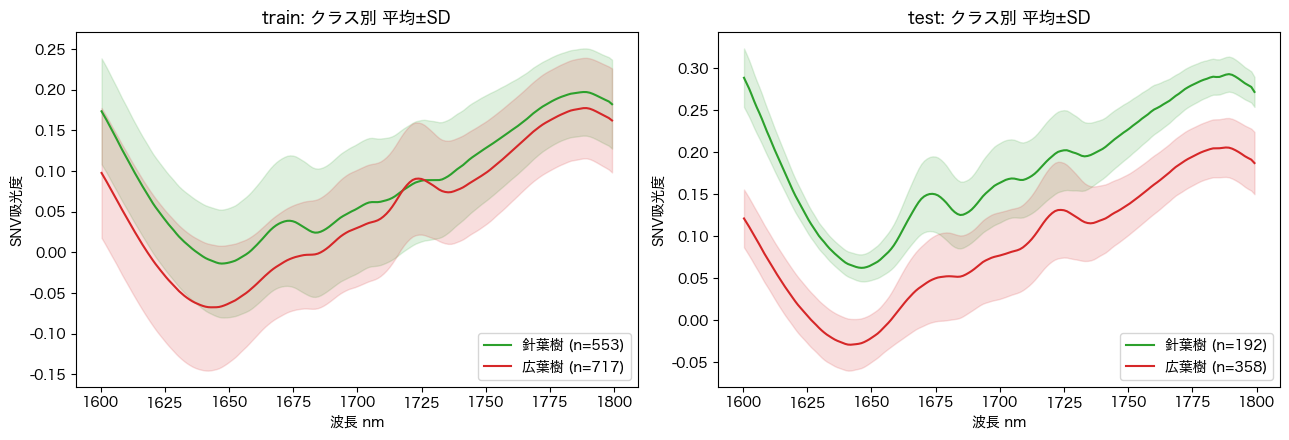

In [5]:
def plot_class(ax,X,y,t):
    for l,c,n in [(1,'tab:green','針葉樹'),(0,'tab:red','広葉樹')]:
        Xc=X[y==l]; m,s=Xc.mean(0),Xc.std(0)
        ax.plot(band_wl,m,color=c,label=f'{n} (n={len(Xc)})'); ax.fill_between(band_wl,m-s,m+s,color=c,alpha=0.15)
    ax.set_xlabel('波長 nm'); ax.set_ylabel('SNV吸光度'); ax.set_title(t); ax.legend()
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
plot_class(ax[0],Xtr,ytr,'train: クラス別 平均±SD'); plot_class(ax[1],Xte,yte,'test: クラス別 平均±SD')
plt.tight_layout(); plt.show()

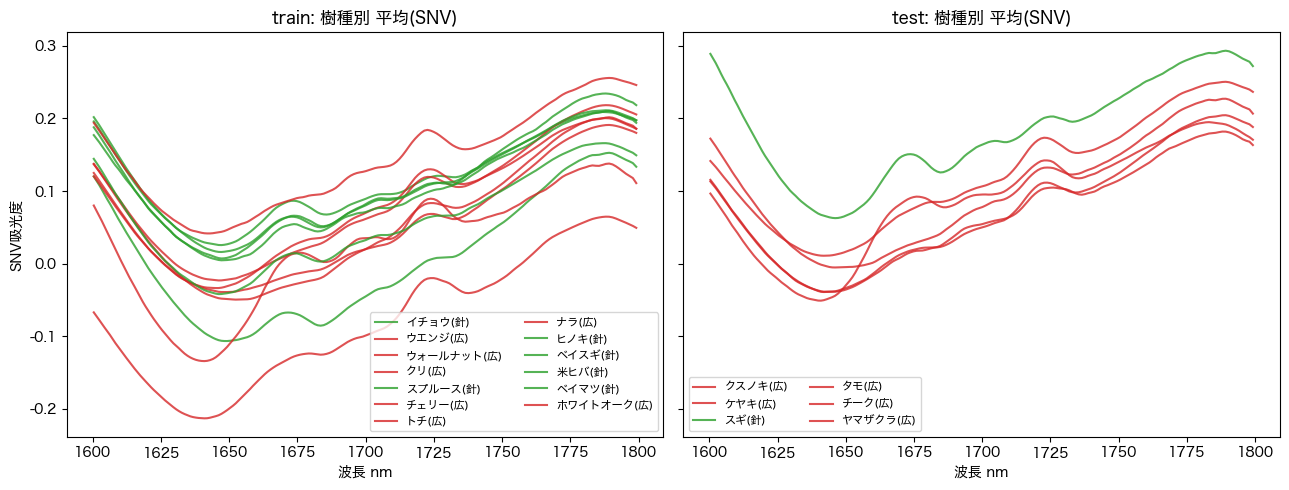

In [6]:
fig,ax=plt.subplots(1,2,figsize=(13,5),sharey=True)
for a,X,g,t in [(ax[0],Xtr,g_tr,'train'),(ax[1],Xte,g_te,'test')]:
    for sp in pd.unique(g):
        Xs=X[g==sp]; l=sp in CONIFER
        a.plot(band_wl,Xs.mean(0),color=('tab:green' if l else 'tab:red'),alpha=.8,
               label=f'{sp}{"(針)" if l else "(広)"}')
    a.set_title(f'{t}: 樹種別 平均(SNV)'); a.set_xlabel('波長 nm'); a.legend(fontsize=8,ncol=2)
ax[0].set_ylabel('SNV吸光度'); plt.tight_layout(); plt.show()

## ③ 1D-CNN による分類(全波長)

全波長のSG2スペクトルを入力。Conv1d+Pool を3段重ね、局所特徴を抽出して階層的に集約する。

In [7]:
class CNN1D(nn.Module):
    def __init__(self,p):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,16,9,padding=4),nn.BatchNorm1d(16),nn.ReLU(),nn.MaxPool1d(4),
            nn.Conv1d(16,32,7,padding=3),nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(4),
            nn.Conv1d(32,64,5,padding=2),nn.BatchNorm1d(64),nn.ReLU(),nn.MaxPool1d(4),
            nn.AdaptiveAvgPool1d(1),nn.Flatten(),nn.Dropout(0.3),nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)
def train_cnn(X,y,epochs=150,lr=1e-3):
    Xt=torch.tensor(X,dtype=torch.float32).unsqueeze(1); yt=torch.tensor(y,dtype=torch.float32)
    m=CNN1D(X.shape[1]); opt=torch.optim.Adam(m.parameters(),lr=lr,weight_decay=1e-4)
    pw=torch.tensor([(y==0).sum()/max((y==1).sum(),1)],dtype=torch.float32)
    lf=nn.BCEWithLogitsLoss(pos_weight=pw); m.train()
    for _ in range(epochs):
        opt.zero_grad(); l=lf(m(Xt),yt); l.backward(); opt.step()
    return m
def predict(m,X):
    m.eval()
    with torch.no_grad():
        return (torch.sigmoid(m(torch.tensor(X,dtype=torch.float32).unsqueeze(1)))>0.5).int().numpy()

In [8]:
# LOSO CV(train内)
rows=[]
for sp in pd.unique(g_tr):
    tri=g_tr!=sp; vai=~tri
    if len(np.unique(ytr[tri]))<2: continue
    m=train_cnn(Xtr[tri],ytr[tri]); p=predict(m,Xtr[vai])
    rows.append((sp,'針葉樹' if ytr[vai][0] else '広葉樹',vai.sum(),accuracy_score(ytr[vai],p)))
loso=pd.DataFrame(rows,columns=['樹種','真クラス','n','acc'])
print(loso.to_string(index=False)); print(f'\nLOSO macro acc = {loso.acc.mean():.3f}')

     樹種 真クラス   n      acc
   イチョウ  針葉樹  94 0.000000
   ウエンジ  広葉樹  87 0.988506
ウォールナット  広葉樹 110 1.000000
     クリ  広葉樹  91 1.000000
  スプルース  針葉樹  97 0.505155
   チェリー  広葉樹  88 0.136364
     トチ  広葉樹 183 0.819672
     ナラ  広葉樹 107 1.000000
    ヒノキ  針葉樹 141 0.553191
   ベイスギ  針葉樹  60 0.883333
    米ヒバ  針葉樹  68 1.000000
   ベイマツ  針葉樹  93 0.892473
ホワイトオーク  広葉樹  51 0.000000

LOSO macro acc = 0.675


In [9]:
# 全trainで最終学習 -> test評価
mf=train_cnn(Xtr,ytr,epochs=180); pt=predict(mf,Xte)
print('test accuracy         :',round(accuracy_score(yte,pt),3))
print('test balanced accuracy:',round(balanced_accuracy_score(yte,pt),3))
cm=confusion_matrix(yte,pt,labels=[0,1]); print('\nconfusion[広,針]行=真\n',cm)
te_r=te.copy(); te_r['pred']=pt
print('\ntest 樹種別 正解率')
print(te_r.groupby([SP,'class']).apply(lambda d:(d.pred==d.label).mean(),include_groups=False).round(3).to_string())

test accuracy         : 1.0
test balanced accuracy: 1.0

confusion[広,針]行=真
 [[358   0]
 [  0 192]]

test 樹種別 正解率
樹種     class
クスノキ   広葉樹      1.0
ケヤキ    広葉樹      1.0
スギ     針葉樹      1.0
タモ     広葉樹      1.0
チーク    広葉樹      1.0
ヤマザクラ  広葉樹      1.0


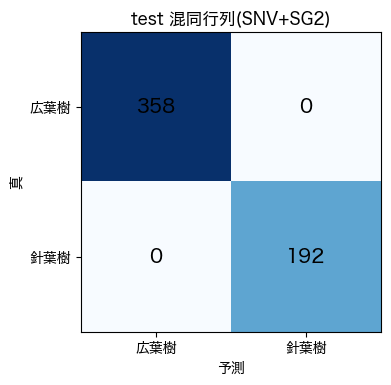

In [10]:
fig,ax=plt.subplots(figsize=(4,4)); ax.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2): ax.text(j,i,cm[i,j],ha='center',va='center',fontsize=14)
ax.set_xticks([0,1]);ax.set_xticklabels(['広葉樹','針葉樹']);ax.set_yticks([0,1]);ax.set_yticklabels(['広葉樹','針葉樹'])
ax.set_xlabel('予測');ax.set_ylabel('真');ax.set_title('test 混同行列(SNV+SG2)');plt.tight_layout();plt.show()

## ④ CNN内部表現の PCA 可視化

目的は分類そのものではなく、**樹種(針/広)を判別する過程でCNNが獲得した内部表現**を取り出すこと。最終線形層の手前(Flatten後の64次元)を埋め込みとみなし、PCAで2次元に落として構造を確認する。この表現が [fft_band_stepwise_features](../docs/fft_band_stepwise_features.md) の特徴と掛け合わさって含水率回帰を改善しうるか、の前段。

embedding dim: 64 | train (1270, 64) test (550, 64)
PC1,PC2 寄与率: [0.736 0.132] 累積 0.868


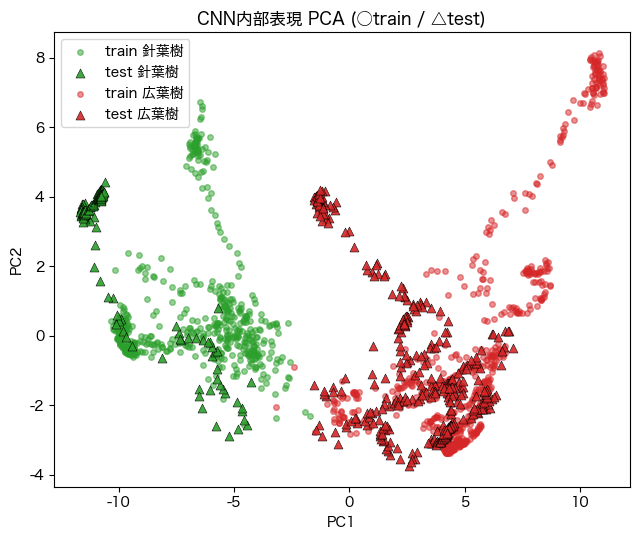

In [11]:
# CNN内部表現(最終線形層手前の64次元埋め込み)を抽出し PCA
from sklearn.decomposition import PCA
def embed(m,X):
    m.eval(); feat=m.net[:-1]   # 末尾Linearを除く=Flatten後64次元(eval時Dropoutは恒等)
    with torch.no_grad():
        return feat(torch.tensor(X,dtype=torch.float32).unsqueeze(1)).numpy()
Etr=embed(mf,Xtr); Ete=embed(mf,Xte)
print('embedding dim:',Etr.shape[1],'| train',Etr.shape,'test',Ete.shape)
pca=PCA(n_components=2).fit(Etr)          # trainでfit(testは未学習樹種)
Ztr=pca.transform(Etr); Zte=pca.transform(Ete)
print('PC1,PC2 寄与率:',pca.explained_variance_ratio_[:2].round(3),
      '累積',round(pca.explained_variance_ratio_[:2].sum(),3))

# PCA① クラス着色(train=○ / test=△)
fig,ax=plt.subplots(figsize=(6.5,5.5))
for lab,c,n in [(1,'tab:green','針葉樹'),(0,'tab:red','広葉樹')]:
    ax.scatter(Ztr[ytr==lab,0],Ztr[ytr==lab,1],s=16,c=c,marker='o',alpha=.5,label=f'train {n}')
    ax.scatter(Zte[yte==lab,0],Zte[yte==lab,1],s=42,c=c,marker='^',edgecolor='k',
               linewidth=.4,alpha=.9,label=f'test {n}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('CNN内部表現 PCA (○train / △test)')
ax.legend(); plt.tight_layout(); plt.show()

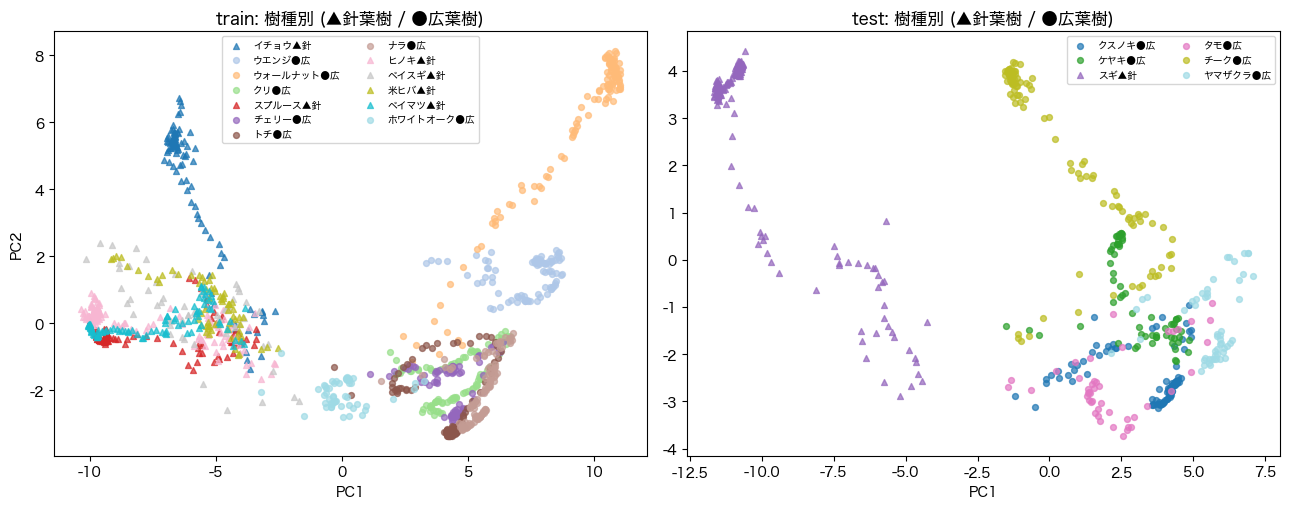

In [12]:
# PCA② 樹種別に着色(クラス内のまとまり/樹種クラスタを確認)
import matplotlib.cm as cm
fig,ax=plt.subplots(1,2,figsize=(13,5.2))
for a,Z,g,t in [(ax[0],Ztr,g_tr,'train'),(ax[1],Zte,g_te,'test')]:
    sps=pd.unique(g); colors=cm.tab20(np.linspace(0,1,len(sps)))
    for sp,col in zip(sps,colors):
        mk='^' if sp in CONIFER else 'o'
        a.scatter(Z[g==sp,0],Z[g==sp,1],s=18,color=col,marker=mk,alpha=.7,
                  label=f'{sp}{"▲針" if sp in CONIFER else "●広"}')
    a.set_title(f'{t}: 樹種別 (▲針葉樹 / ●広葉樹)')
    a.set_xlabel(f'PC1'); a.legend(fontsize=7,ncol=2)
ax[0].set_ylabel('PC2'); plt.tight_layout(); plt.show()

## ⑤ 内部表現 × fft_band特徴 → 含水率回帰の改善検証(リーク無しLOSO)

[fft_band_stepwise_features](../docs/fft_band_stepwise_features.md) の確定5特徴を再構成し、これに **CNN内部表現(樹種文脈)** を加えた/掛け合わせた場合に LOSO macro-RMSE が改善するか検証する。

**リーク防止が肝**: CNN埋め込みは各foldで「その樹種を除いて学習したCNN」から抽出する([[loso-validation-and-leakage]])。fft特徴は行単位なので全体一括計算で可。RFはfold内学習。

比較3条件:
- **base**: fft5特徴のみ
- **+emb**: fft5 + 埋め込みPCA(4成分)を連結
- **+interact**: fft5 + PC4 + **fft5⊗PC4 の交互作用積(5×4=20)** ← 「樹種文脈で特徴を変調」

注: base自体の5特徴は全trainで選択した楽観値だが、3条件で同一なので**埋め込み寄与の比較は公平**。

In [13]:
# fft_band 確定5特徴を再構成(行単位=リーク無し) ※ doc準拠
mc = tr['含水率'].values                                  # 回帰ターゲット(testに含水率は無い)
nm_order=np.argsort(wl); nm=wl[nm_order]
Xraw=tr[wn_cols].values.astype(float)[:,nm_order]         # nm昇順 生スペクトル
def fft_denoise(X,keep_frac):                             # 弱マスク平滑化
    n=X.shape[1]; ifg=np.fft.fftshift(np.fft.ifft(X,axis=1),axes=1); c=n//2
    r=max(1,int(round(keep_frac*n/2))); ifg[:,:c-r]=0; ifg[:,c+r+1:]=0
    return np.fft.fft(np.fft.ifftshift(ifg,axes=1),axis=1).real
def snv1(M): return (M-M.mean(1,keepdims=True))/(M.std(1,keepdims=True)+1e-8)
sg=lambda M,d: savgol_filter(M,11,2,deriv=d,axis=1)
bmask=lambda lo,hi:(nm>=lo)&(nm<=hi)
def f_max(E): return E.max(1)
def f_min(E): return E.min(1)
def f_slope(E,w): w0=w-w.mean(); return (E*w0).sum(1)/(w0**2).sum()
def f_crdepth(E,w):
    t=(w-w[0])/(w[-1]-w[0]); line=E[:,[0]]*(1-t)[None]+E[:,[-1]]*t[None]
    return (line-E).max(1)

weak=fft_denoise(Xraw,0.15)
sg1_snv_orig=sg(snv1(Xraw),1); sg1_snv_weak=sg(snv1(weak),1); sg2_weak=sg(weak,2); snv_orig=snv1(Xraw)
m1=bmask(2000,2100); m2=bmask(2020,2100); m3=bmask(1430,1470)
FFT5=np.column_stack([
    f_max(sg1_snv_orig[:,m1]),                 # snv_sg1_2000_2100|max
    f_crdepth(sg1_snv_weak[:,m2],nm[m2]),      # snv_sg1_2020_2100|cr_depth
    f_min(sg2_weak[:,m3]),                      # raw_sg2_1430_1470|min
    f_slope(snv_orig[:,m3],nm[m3]),            # snv_1430_1470|slope
    f_crdepth(sg1_snv_orig[:,m1],nm[m1]),      # snv_sg1_2000_2100|cr_depth
])
FFT_NAMES=['snv_sg1_2000_2100|max','snv_sg1_2020_2100|cr_depth','raw_sg2_1430_1470|min',
           'snv_1430_1470|slope','snv_sg1_2000_2100|cr_depth']
print('FFT5',FFT5.shape,'| MC範囲 %.1f-%.1f%%'%(mc.min(),mc.max()))

FFT5 (1270, 5) | MC範囲 0.8-298.6%


In [14]:
# リーク無しLOSO: 各foldでCNN学習→埋め込み→fft特徴と連結/交互作用→RF回帰
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
KPC=4
def rf(): return RandomForestRegressor(n_estimators=300,random_state=0,n_jobs=-1)
def rmse(a,b): return float(np.sqrt(((a-b)**2).mean()))
res={'base':[],'+emb':[],'+interact':[]}
for sp in pd.unique(g_tr):
    tri=g_tr!=sp; vai=~tri
    # --- fold内CNN(その樹種を除外して学習) → 埋め込み ---
    m=train_cnn(Xtr[tri],ytr[tri],epochs=120)
    E=embed(m,Xtr)                                   # 全行64次元
    sc=StandardScaler().fit(E[tri]); pca_f=PCA(KPC).fit(sc.transform(E[tri]))
    P=pca_f.transform(sc.transform(E))               # 全行 KPC次元
    inter=np.einsum('ni,nj->nij',FFT5,P).reshape(len(P),-1)  # fft5⊗PC
    feats={'base':FFT5,'+emb':np.hstack([FFT5,P]),'+interact':np.hstack([FFT5,P,inter])}
    for k,F in feats.items():
        r=rf().fit(F[tri],mc[tri]); res[k].append((sp,vai.sum(),rmse(mc[vai],r.predict(F[vai]))))
tab=pd.DataFrame({'樹種':[x[0] for x in res['base']],'n':[x[1] for x in res['base']]})
for k in res: tab[k]=[x[2] for x in res[k]]
print(tab.round(2).to_string(index=False))
print('\n=== LOSO macro-RMSE (樹種等重み) ===')
for k in res: print(f'  {k:10s}: {np.mean([x[2] for x in res[k]]):.2f}')

     樹種   n  base  +emb  +interact
   イチョウ  94 23.53 30.30      28.83
   ウエンジ  87 11.86 15.65      17.60
ウォールナット 110 12.91 12.99      13.08
     クリ  91 13.03 18.97      19.52
  スプルース  97 11.34 12.30      11.40
   チェリー  88 23.59 29.54      29.01
     トチ 183  8.29 13.16      10.23
     ナラ 107  8.39 16.62      18.88
    ヒノキ 141 13.56 14.68      12.04
   ベイスギ  60 59.12 76.44      75.39
    米ヒバ  68 12.01  7.97       9.94
   ベイマツ  93  9.91  7.34      12.47
ホワイトオーク  51 15.50 16.89      16.76

=== LOSO macro-RMSE (樹種等重み) ===
  base      : 17.16
  +emb      : 20.99
  +interact : 21.17


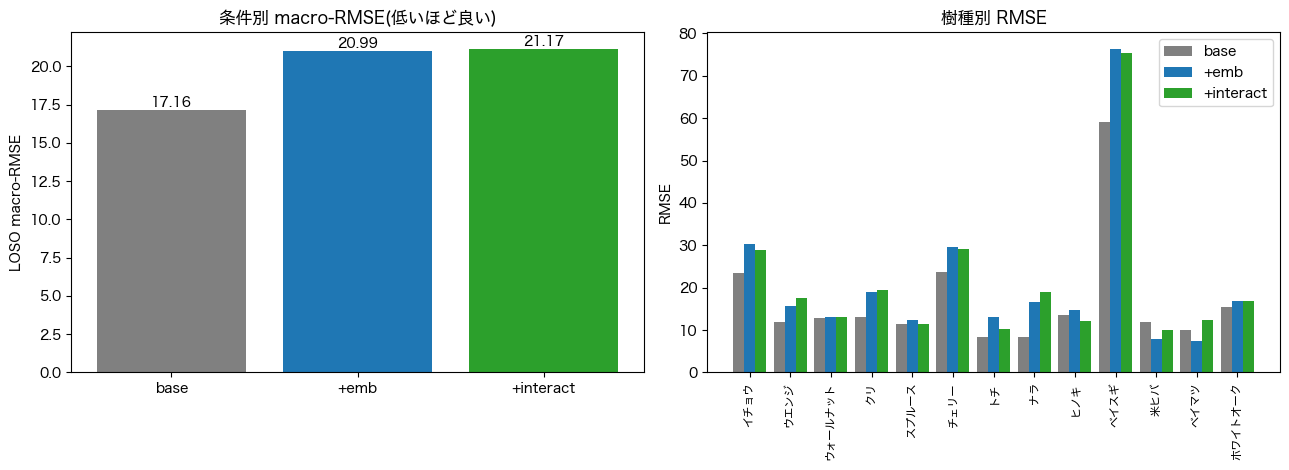

In [15]:
# 可視化: 条件別 macro-RMSE と 樹種別RMSE
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
macros={k:np.mean([x[2] for x in v]) for k,v in res.items()}
ax[0].bar(macros.keys(),macros.values(),color=['gray','tab:blue','tab:green'])
for i,(k,v) in enumerate(macros.items()): ax[0].text(i,v,f'{v:.2f}',ha='center',va='bottom')
ax[0].set_ylabel('LOSO macro-RMSE'); ax[0].set_title('条件別 macro-RMSE(低いほど良い)')
x=np.arange(len(tab)); w=0.27
for i,(k,c) in enumerate([('base','gray'),('+emb','tab:blue'),('+interact','tab:green')]):
    ax[1].bar(x+(i-1)*w,tab[k],w,label=k,color=c)
ax[1].set_xticks(x); ax[1].set_xticklabels(tab['樹種'],rotation=90,fontsize=8)
ax[1].set_ylabel('RMSE'); ax[1].set_title('樹種別 RMSE'); ax[1].legend()
plt.tight_layout(); plt.show()

## ⑥ 樹種ゲーティング検証 — データ分割の損得を実測

埋め込み連結(⑤)は悪化したので、**CNNの針/広シグナルを最小限/構造的に使う**3条件をLOSOで比較:

- **base**: fft5のみ・RF1個（全樹種, 約1180行/fold）
- **+prob**: fft5 + **針葉樹確率1列**（fold内CNNのsigmoid出力）。データ減らさず文脈を1次元だけ注入
- **gate(A1)**: 予測クラスで **針葉樹RF / 広葉樹RF を切替**。各エキスパートは同群のみ(約460〜650行)で学習

確率・予測クラスは「その樹種を除外して学習したfold内CNN」由来＝リーク無し。

In [16]:
# リーク無しLOSO: base / +prob / gate(A1)
def proba(m,X):
    m.eval()
    with torch.no_grad():
        return torch.sigmoid(m(torch.tensor(X,dtype=torch.float32).unsqueeze(1))).numpy()
res2={'base':[],'+prob':[],'gate(A1)':[]}
for sp in pd.unique(g_tr):
    tri=g_tr!=sp; vai=~tri
    m=train_cnn(Xtr[tri],ytr[tri],epochs=120)
    p=proba(m,Xtr)                               # 全行 針葉樹確率
    cpred=(p>0.5).astype(int)                    # 予測クラス
    # base
    rb=rf().fit(FFT5[tri],mc[tri]); rmse_b=rmse(mc[vai],rb.predict(FFT5[vai]))
    # +prob (確率1列を連結)
    Fp=np.hstack([FFT5,p[:,None]])
    rp=rf().fit(Fp[tri],mc[tri]); rmse_p=rmse(mc[vai],rp.predict(Fp[vai]))
    # gate(A1): 予測クラスで針/広RFを切替(エキスパートは学習側の各クラスのみで学習)
    pred_g=np.empty(vai.sum())
    for cls in (0,1):
        sub=tri&(ytr==cls)
        if sub.sum()==0: continue
        rg=rf().fit(FFT5[sub],mc[sub])
        vmask=cpred[vai]==cls
        if vmask.any(): pred_g[vmask]=rg.predict(FFT5[vai][vmask])
    rmse_g=rmse(mc[vai],pred_g)
    for k,v in [('base',rmse_b),('+prob',rmse_p),('gate(A1)',rmse_g)]:
        res2[k].append((sp,vai.sum(),v))
tab2=pd.DataFrame({'樹種':[x[0] for x in res2['base']],'n':[x[1] for x in res2['base']]})
for k in res2: tab2[k]=[x[2] for x in res2[k]]
print(tab2.round(2).to_string(index=False))
print('\n=== LOSO macro-RMSE ===')
for k in res2: print(f'  {k:9s}: {np.mean([x[2] for x in res2[k]]):.2f}')

     樹種   n  base  +prob  gate(A1)
   イチョウ  94 23.53  23.01     21.96
   ウエンジ  87 11.86  12.63     16.40
ウォールナット 110 12.91  19.71     13.45
     クリ  91 13.03  16.35     37.87
  スプルース  97 11.34  11.25     17.48
   チェリー  88 23.59  23.36     36.61
     トチ 183  8.29   8.73      7.90
     ナラ 107  8.39   9.29      7.27
    ヒノキ 141 13.56  15.56     22.25
   ベイスギ  60 59.12  62.59     87.40
    米ヒバ  68 12.01  10.88     12.71
   ベイマツ  93  9.91  10.30      9.25
ホワイトオーク  51 15.50  19.74     17.79

=== LOSO macro-RMSE ===
  base     : 17.16
  +prob    : 18.72
  gate(A1) : 23.72


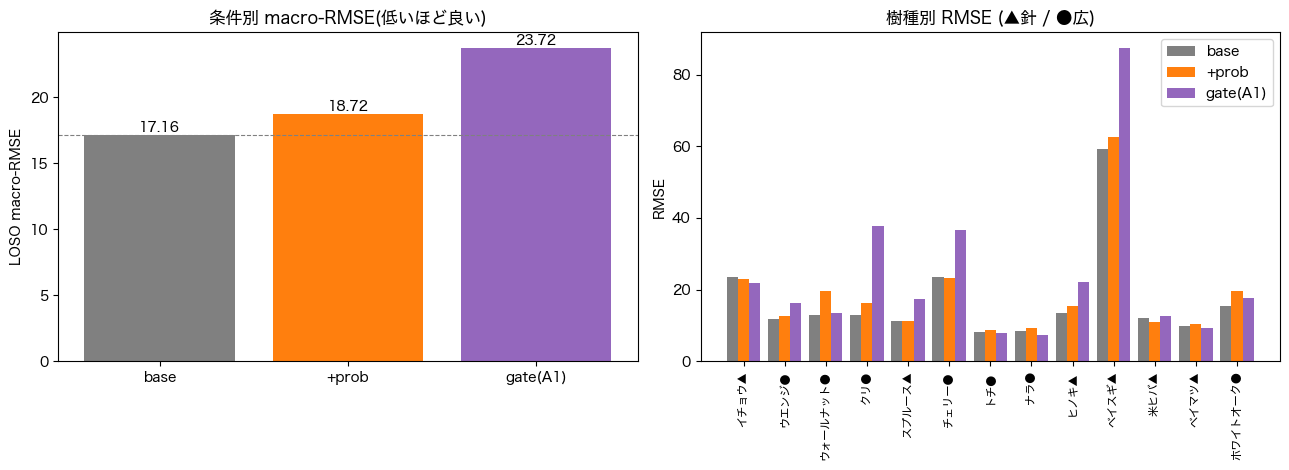

In [17]:
# 可視化: 条件別 macro-RMSE と 樹種別RMSE(針/広で色分け)
fig,ax=plt.subplots(1,2,figsize=(13,4.8))
macros2={k:np.mean([x[2] for x in v]) for k,v in res2.items()}
cols=['gray','tab:orange','tab:purple']
ax[0].bar(macros2.keys(),macros2.values(),color=cols)
for i,(k,v) in enumerate(macros2.items()): ax[0].text(i,v,f'{v:.2f}',ha='center',va='bottom')
ax[0].axhline(macros2['base'],color='gray',ls='--',lw=.8)
ax[0].set_ylabel('LOSO macro-RMSE'); ax[0].set_title('条件別 macro-RMSE(低いほど良い)')
x=np.arange(len(tab2)); w=0.27
for i,(k,c) in enumerate(zip(res2,cols)):
    ax[1].bar(x+(i-1)*w,tab2[k],w,label=k,color=c)
ax[1].set_xticks(x)
ax[1].set_xticklabels([f'{s}{"▲" if s in CONIFER else "●"}' for s in tab2['樹種']],rotation=90,fontsize=8)
ax[1].set_ylabel('RMSE'); ax[1].set_title('樹種別 RMSE (▲針 / ●広)'); ax[1].legend()
plt.tight_layout(); plt.show()